# Customer churn: from a model score to a review decision

This notebook executes the shared training code, audits the dataset, compares five candidates, checks an engineered feature, and explains the resulting review workload. Outputs are produced by running these cells, not pasted from an earlier analysis.

The supplied Telco dataset is an educational benchmark. Genuine calculations on it are not evidence of commercial savings or production deployment. See the final report for provenance and limitations.

In [1]:
# Resolve paths from the repository root or the notebooks directory.
from pathlib import Path
import sys
ROOT = Path.cwd().resolve()
if not (ROOT / 'src/train.py').exists():
    ROOT = ROOT.parent
assert (ROOT / 'src/train.py').exists(), 'Start Jupyter in this repository.'
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
import json
import numpy as np
import pandas as pd
from IPython.display import display, Markdown, Image
from src.preprocessing import get_feature_target, clean
from src.train import make_splits, run
from src.evaluation import measure
from src.predict import load_artifacts, score_customers
raw = pd.read_csv(ROOT / 'data/raw/telco_churn.csv')
X, y = get_feature_target(raw)
splits = make_splits(X, y)
print(f'{len(raw):,} rows; {len(raw.columns)} columns; {X.shape[1]} raw predictors.')

7,043 rows; 21 columns; 19 raw predictors.


## 1. Audit data before modelling
`customerID` is a join key, not a predictor. The label is excluded from every model input. Numerical missingness is handled inside the fitted pipeline. The structural audit covers all rows; feature/label exploration below is restricted to training rows.

In [2]:
audit = pd.Series({
    'Rows': len(raw), 'Churn labels': int(y.sum()), 'Churn fraction': y.mean(),
    'Duplicate IDs': int(raw.customerID.duplicated().sum()),
    'Blank TotalCharges': int(raw.TotalCharges.astype(str).str.strip().eq('').sum())
})
display(audit.to_frame('value'))
display(pd.DataFrame([
    {'split': name, 'rows': len(idx), 'churners': int(y.iloc[idx].sum())}
    for name, idx in splits.items()
]))

,value
Rows,7043.00000
Churn labels,1869.00000
Churn fraction,0.26537
Duplicate IDs,0.00000
Blank TotalCharges,11.00000


,split,rows,churners
0,train,4225,1121
1,validation,1409,374
2,test,1409,374


## 2. Training-only exploration
Group rates describe associations in these rows. They cannot establish why customers leave or whether an intervention works. No industry-wide annual churn claim is inferred from this sample.

In [3]:
train_raw = raw.iloc[splits['train']].copy()
train_raw['Churn'] = y.iloc[splits['train']]
for column in ['Contract', 'InternetService']:
    display(train_raw.groupby(column).Churn.agg(customers='count', churners='sum', churn_fraction='mean'))
display(clean(train_raw)[['tenure', 'MonthlyCharges', 'TotalCharges', 'AvgMonthlySpend']].describe())

,customers,churners,churn_fraction
Contract,,,
Month-to-month,2312,993,0.429498
One year,885,103,0.116384
Two year,1028,25,0.024319


,customers,churners,churn_fraction
InternetService,,,
DSL,1451,281,0.193660
Fiber optic,1842,766,0.415852
No,932,74,0.079399


,tenure,MonthlyCharges,TotalCharges,AvgMonthlySpend
count,4225.000000,4225.000000,4225.000000,4225.000000
mean,32.618935,64.419302,2280.123775,64.400247
std,24.510359,30.161657,2257.726397,30.275560
min,0.000000,18.250000,0.000000,13.775000
25%,9.000000,35.050000,403.350000,35.000000
50%,30.000000,70.000000,1417.900000,69.750000
75%,55.000000,89.850000,3729.750000,90.178302
max,72.000000,118.750000,8684.800000,120.630282


## 3. Refit and evaluate the shared implementation
Each model gets five-fold cross-validation on the 60% training partition. Selection uses **average precision**. The 20% validation partition chooses the highest cutoff achieving at least 80% recall. The final 20% is evaluated only after those choices are locked.

The original project had already inspected this public dataset. A new seed enforces this run's separation; it does not create independent external validation. Hyperparameters and the 80% target are fixed design choices, not chosen to improve the test results.

This cell performs the actual fits and overwrites generated artifacts. It also records a training log.

In [4]:
# Tee training output into both this notebook and an auditable text log.
import contextlib
import io
class Tee(io.TextIOBase):
    def __init__(self, *streams):
        self.streams = streams
    def write(self, text):
        for stream in self.streams:
            stream.write(text)
            stream.flush()
        return len(text)
    def flush(self):
        for stream in self.streams:
            stream.flush()
(ROOT / 'reports').mkdir(exist_ok=True)
with (ROOT / 'reports/training.log').open('w') as log:
    with contextlib.redirect_stdout(Tee(sys.stdout, log)):
        metrics = run(output_root=ROOT)
print('Selected model:', metrics['selected_model'])

DATA AUDIT {"rows": 7043, "columns": 21, "predictors": 19, "churners": 1869, "churn_fraction": 0.2653698707936959, "duplicate_ids": 0, "blank_total_charges": 11, "splits": {"train": {"rows": 4225, "churners": 1121}, "validation": {"rows": 1409, "churners": 374}, "test": {"rows": 1409, "churners": 374}}}
dummy_prior {"cv_average_precision": 0.26532544378698225, "cv_ap_std": 0.00047337278106509564, "cv_roc_auc": 0.5, "cv_auc_std": 0.0, "fit_and_cv_seconds": 0.549}
xgboost {"cv_average_precision": 0.6479089077890512, "cv_ap_std": 0.02553595108739851, "cv_roc_auc": 0.8383000749497244, "cv_auc_std": 0.00760209507141823, "fit_and_cv_seconds": 1.237}
logistic_regression {"cv_average_precision": 0.6569592635006006, "cv_ap_std": 0.02848572901154594, "cv_roc_auc": 0.8458667345666644, "cv_auc_std": 0.008534176318870096, "fit_and_cv_seconds": 0.597}
random_forest {"cv_average_precision": 0.6532341669521715, "cv_ap_std": 0.028097800000266734, "cv_roc_auc": 0.8438354864682355, "cv_auc_std": 0.009749

## 4. Model comparison
Test F1 in this table uses a common 0.5 threshold. The selected model's operational cutoff is evaluated separately below. Small differences in CV scores should not be presented as decisive superiority.

,model,cv_average_precision,cv_ap_std,cv_roc_auc,test_roc_auc,test_average_precision,test_f1
0,dummy_prior,0.2653,0.0005,0.5000,0.5000,0.2654,0.0000
1,xgboost,0.6479,0.0255,0.8383,0.8431,0.6626,0.5869
2,logistic_regression,0.6570,0.0285,0.8459,0.8402,0.6563,0.6006
3,random_forest,0.6532,0.0281,0.8438,0.8474,0.6790,0.5807
4,hist_gradient_boosting,0.6558,0.0262,0.8430,0.8418,0.6649,0.5954


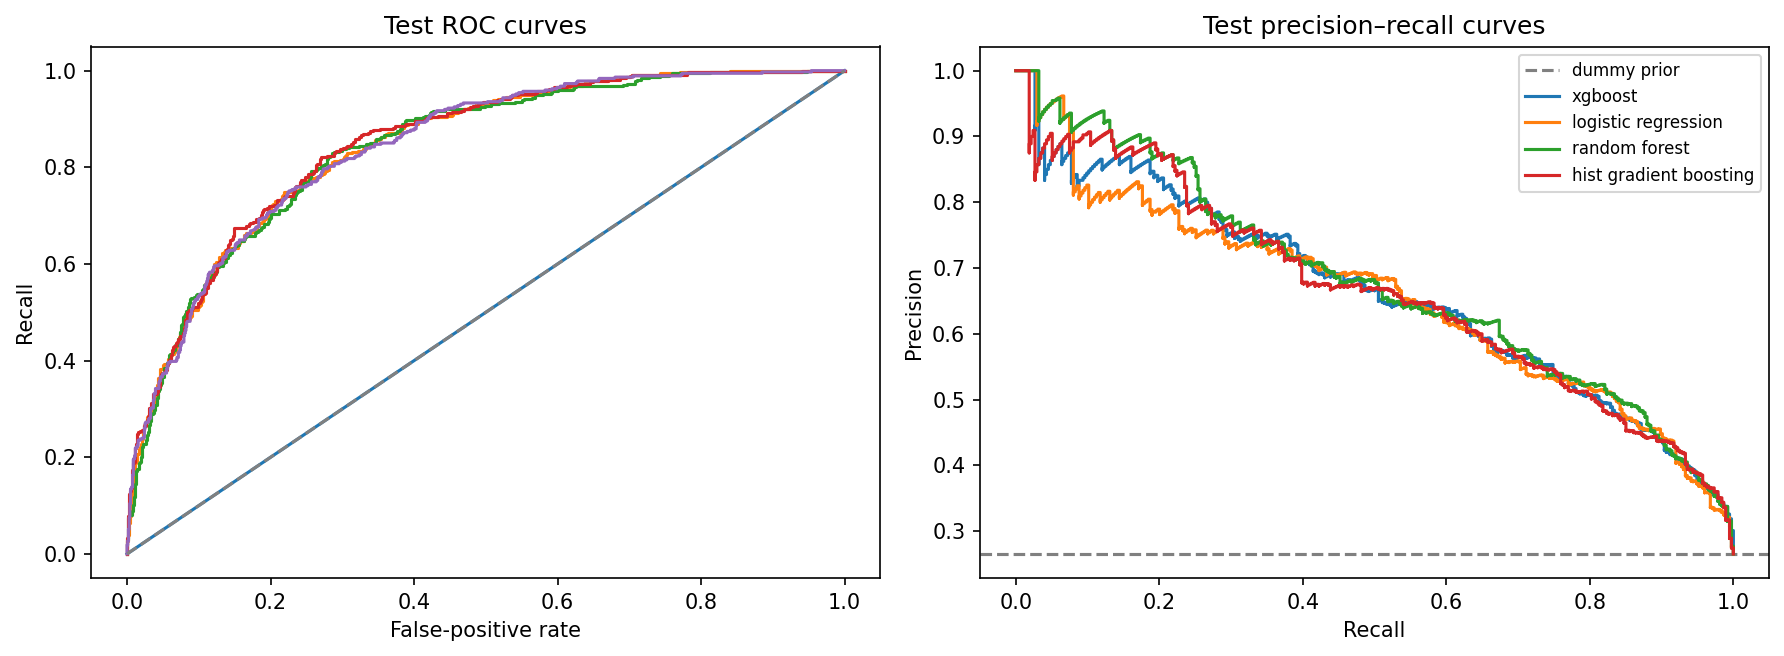

In [5]:
comparison = pd.read_csv(ROOT / 'reports/model_comparison.csv')
display(comparison[['model','cv_average_precision','cv_ap_std','cv_roc_auc',
                    'test_roc_auc','test_average_precision','test_f1']].round(4))
display(Image(filename=str(ROOT / 'reports/figures/model_curves.png')))

## 5. Explain the decision trade-off
Recall describes the fraction of observed churners caught; precision describes the fraction of flagged customers who churned. A retention team needs both, together with the number of profiles it must review.

,threshold,flagged,tp,fp,fn,precision,recall,f1
default cutoff 0.5,0.500000,332,212,120,162,0.638554,0.566845,0.600567
validation cutoff,0.272015,589,302,287,72,0.512733,0.807487,0.627207


At cutoff **0.2720**, validation recall is **80.2%**.
On the test set, **302 churners are flagged**, **72 are missed**, and **287 non-churners are flagged**.
That requires reviewing **589 profiles**, with **51.3% precision** and **80.7% recall**.
This is a review workload, not a count of prevented churn events.

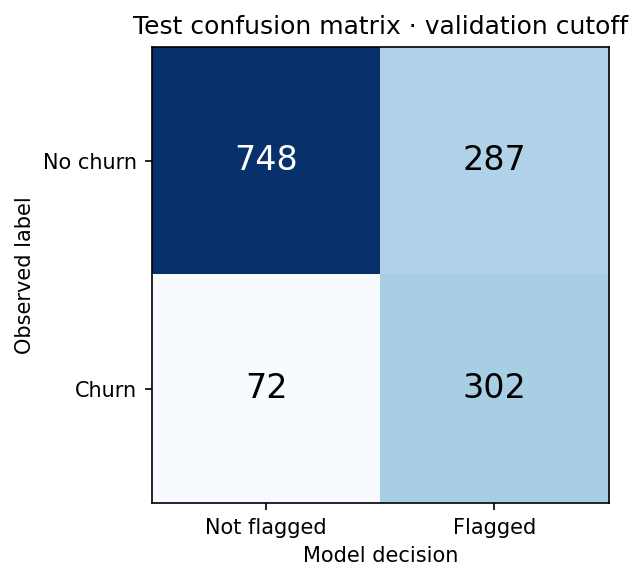

In [6]:
t = metrics['test']
v = metrics['validation']
display(pd.DataFrame([metrics['comparison'][metrics['selected_model']]['test_at_0_5'], t],
                     index=['default cutoff 0.5', 'validation cutoff'])[
                         ['threshold','flagged','tp','fp','fn','precision','recall','f1']])
display(Markdown(f"""At cutoff **{metrics['threshold']:.4f}**, validation recall is **{v['recall']:.1%}**.
On the test set, **{t['tp']} churners are flagged**, **{t['fn']} are missed**, and **{t['fp']} non-churners are flagged**.
That requires reviewing **{t['flagged']} profiles**, with **{t['precision']:.1%} precision** and **{t['recall']:.1%} recall**.
This is a review workload, not a count of prevented churn events."""))
display(Image(filename=str(ROOT / 'reports/figures/confusion_matrix.png')))

## 6. Uncertainty, capacity, and calibration
Bootstrap intervals describe uncertainty conditional on this fitted model and test sample. They do not include retraining or distribution shift. The top-20% comparison is a fixed capacity scenario, not a profit calculation.

,2.5th percentile,97.5th percentile
roc_auc,0.818343,0.860934
average_precision,0.607292,0.704866
precision,0.469445,0.551461
recall,0.769534,0.843016


Reviewing the top **282** profiles captures **193** churners:
**51.6% recall**, **68.4% precision**, and **2.58×** the random-selection positive rate.
Scores have not been recalibrated; a good ranking score alone does not prove reliable probabilities.

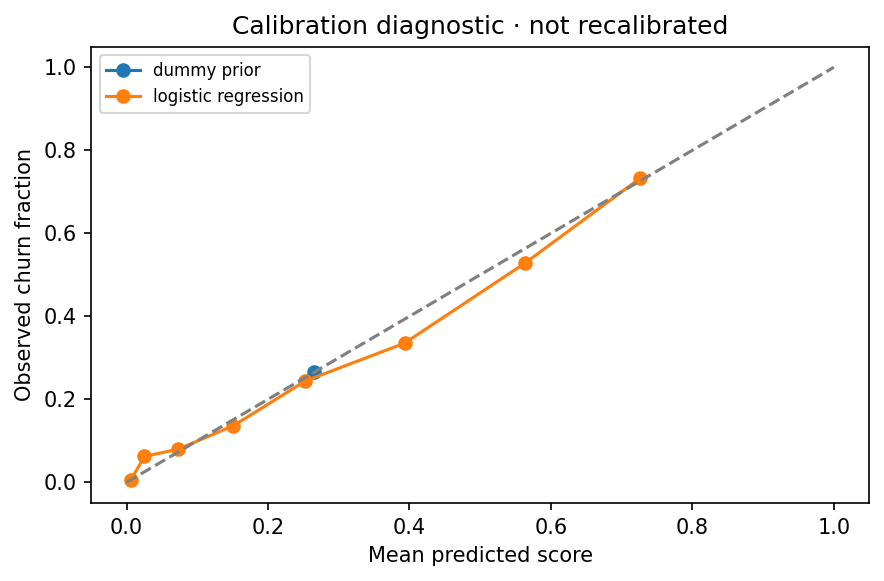

In [7]:
display(pd.DataFrame(metrics['test_95pct_bootstrap_intervals'], index=['2.5th percentile','97.5th percentile']).T)
cap = metrics['test_top20pct']
display(Markdown(f"""Reviewing the top **{cap['contacts']}** profiles captures **{cap['churners_captured']}** churners:
**{cap['recall']:.1%} recall**, **{cap['precision']:.1%} precision**, and **{cap['lift_over_random']:.2f}×** the random-selection positive rate.
Scores have not been recalibrated; a good ranking score alone does not prove reliable probabilities."""))
display(Image(filename=str(ROOT / 'reports/figures/calibration.png')))

## 7. Was feature engineering useful?
The spending ratio is compared with a version of logistic regression without it, using the same five training folds. This is a descriptive ablation, not an extra test-driven model-selection step.

In [8]:
ablation = metrics['spend_ablation']
display(pd.Series(ablation).to_frame('result'))
display(Markdown(f"The mean paired CV AP change is **{ablation['mean_difference']:+.4f}**. A small change is not evidence of a dependable business benefit."))

,result
without_spend_cv_ap,0.657609
with_spend_cv_ap,0.656959
paired_fold_differences,"[-0.002379148246572149, 0.00027377915678072906..."
mean_difference,-0.00065


The mean paired CV AP change is **-0.0007**. A small change is not evidence of a dependable business benefit.

## 8. Global model explanation
Permutation importance measures how average precision changes when a feature is shuffled. It is not SHAP and does not explain causal mechanisms. It is calculated after stateless cleaning, so billing ratios and related raw features can become inconsistent during permutations. Correlated inputs can mask or share importance.

,feature,mean_ap_decrease,std_ap_decrease
0,tenure,0.282750,0.014119
1,TotalCharges,0.082927,0.007657
2,Contract,0.047236,0.013805
3,InternetService,0.024562,0.009253
4,AvgMonthlySpend,0.011727,0.003654
5,TechSupport,0.010824,0.006513
6,PaymentMethod,0.009616,0.003633
7,MultipleLines,0.009568,0.005461
8,PaperlessBilling,0.008627,0.004157
9,PhoneService,0.008428,0.002014


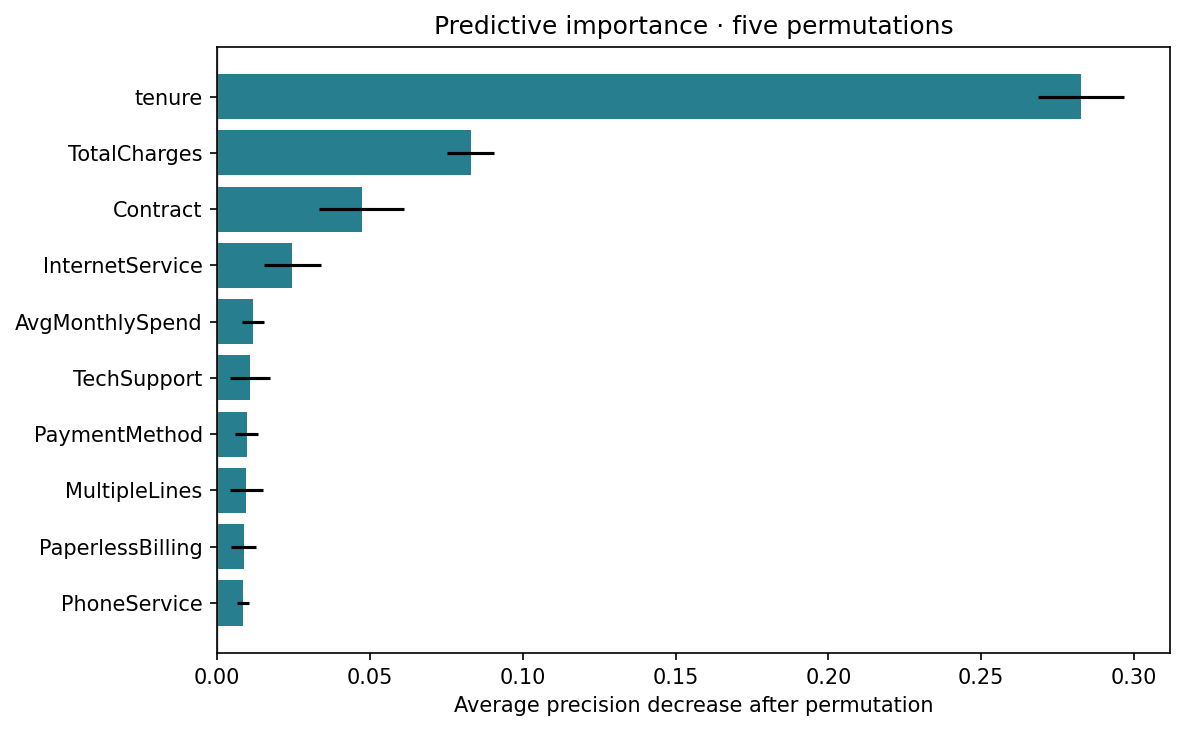

,group,value,n,churners,recall,precision,false_positive_rate
0,gender,Female,672,189,0.825397,0.534247,0.281573
1,gender,Male,737,185,0.789189,0.491582,0.273551
2,SeniorCitizen,0,1172,277,0.772563,0.502347,0.236872
3,SeniorCitizen,1,237,97,0.907216,0.539877,0.535714


Subgroup error rates are descriptive and sample-dependent. This is not a fairness certification.

In [9]:
display(pd.read_csv(ROOT / 'reports/permutation_importance.csv').head(10))
display(Image(filename=str(ROOT / 'reports/figures/permutation_importance.png')))
display(pd.read_csv(ROOT / 'reports/subgroup_metrics.csv'))
display(Markdown('Subgroup error rates are descriptive and sample-dependent. This is not a fairness certification.'))

## 9. Verify predictions independently
Load the newly trained pipeline, regenerate scores from the saved source rows, and recompute the report metrics. This links the model artifact, original data, and claimed results.

In [10]:
pipeline, saved_metrics = load_artifacts(ROOT)
predictions = pd.read_csv(ROOT / 'reports/test_predictions.csv')
recomputed = measure(predictions.y_true, predictions.churn_score, saved_metrics['threshold'])
for key, value in recomputed.items():
    assert np.isclose(value, saved_metrics['test'][key]), key
profiles = raw.iloc[predictions.source_row].drop(columns='Churn')
fresh = score_customers(profiles, pipeline, saved_metrics['threshold'])
np.testing.assert_allclose(fresh.churn_score, predictions.churn_score, rtol=1e-10)
print(f'Verified all {len(predictions):,} saved holdout scores and every reported test metric.')
display(fresh[['customerID','churn_score','flagged_for_review']].head())

Verified all 1,409 saved holdout scores and every reported test metric.


,customerID,churn_score,flagged_for_review
3869,1357-BIJKI,0.330173,1
6455,2478-EEWWM,0.158875,0
4273,3814-MLAXC,0.327201,1
3337,0840-DFEZH,0.740675,1
345,0021-IKXGC,0.810527,1


## 10. Conclusions and next steps
The defensible portfolio outcome is a reproducible decision-support prototype with visible errors and limitations. It is not a claim that a model prevents churn, that demographic error rates are equitable, or that retrospective snapshot inputs are all available before a real future churn event.

Before operational use: define the prediction horizon, audit feature timing, validate on later customers, choose a commercial threshold with stakeholders, and test outreach against a randomised control group. Read `reports/RESULTS.md` for the full generated interpretation and `reports/REVIEW.md` for implemented changes.

In [11]:
manifest = json.loads((ROOT / 'reports/run_manifest.json').read_text())
display(pd.Series({'python': manifest['python'],
                   'dataset_sha256': manifest['data_sha256'], 'seed': manifest['seed'],
                   'selected_model': metrics['selected_model']}).to_frame('provenance'))
display(pd.Series(manifest['versions']).to_frame('executed_version'))

,provenance
run_utc,2026-09-15T08:20:21.642052+00:00
python,3.12.14
dataset_sha256,16320c9c1ec72448db59aa0a26a0b95401046bef5d02fd...
seed,2026
selected_model,logistic_regression


,executed_version
numpy,2.3.5
pandas,2.2.3
scikit-learn,1.8.0
scipy,1.17.0
matplotlib,3.10.8
joblib,1.5.3
threadpoolctl,3.6.0
xgboost,3.4.1
